<div align="center">

# Universidad Tecnologica de Xicotepec de Juarez

# Práctica 11: Algoritmos de Análisis No Supervisado, Clientes de Centros Comerciales

 **Estudiante:** Jonathan Blademar Ramirez Reyes

**Grupo:** 9B — Ingeniería en Desarrollo y Gestión de Software

**Fecha:** 08/08/2026

**Título:** Segmentación de clientes mediante K-Means y análisis exploratorio de datos

</div>

**Objetivo:** Replicar, traducir, analizar y documentar el notebook “Unsupervised Learning: 3-6 Clusters | K-Means | EDA”, con la finalidad de aplicar las etapas fundamentales de un proceso de aprendizaje no supervisado para la segmentación de clientes.

El estudiante realizará la exploración, limpieza, transformación y normalización del conjunto de datos Mall_Customers.csv; aplicará el algoritmo K-Means sobre diferentes combinaciones de variables; determinará el número adecuado de clústeres mediante el método del codo y el coeficiente de silueta; visualizará e interpretará los grupos encontrados y comparará los resultados obtenidos con datos originales y normalizados.

---

# <center>Segmentación de Clientes del Centro Comercial</center>

### Objetivo :
- Clasificar / agrupar a los Clientes del Centro Comercial según características numéricas y categóricas.
- Es un planteamiento de problema de **Aprendizaje No Supervisado**.

### <center>Atributos del Dataset</center>
    
- **CustomerID** : ID único asignado al cliente
- **Gender** : Género del cliente
- **Age** : Edad del cliente
- **Annual Income (k\$)** : Ingreso anual del cliente
- **Spending Score (1-1000)** : Puntaje asignado por el centro comercial según el comportamiento y la naturaleza de gasto del cliente

### Contenido del Notebook :
- Información del Dataset
- Análisis Exploratorio de Datos (EDA)
- Resumen del EDA
- Ingeniería de Características
- Modelado
- Conclusión

### Qué aprenderás :
- Técnicas de Visualización de Datos. 
- Información sobre el Algoritmo de Clustering K-Means.
- Pruebas estadísticas para la selección de hiperparámetros.
- Diferencia en el rendimiento del modelo cuando se entrena con el dataset original y con el dataset normalizado.

### Trabajo Reciente :

- [Clasificación Binaria](https://www.kaggle.com/competitions/titanic/discussion/352223) **: Describe el enfoque necesario para abordar problemas de Clasificación Binaria, explicado a través de notebooks que contienen trabajo realizado sobre datasets con código fácil y entendible.**
- [Análisis de Series de Tiempo](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/discussion/352205) **: Describe los conceptos básicos del Análisis de Series de Tiempo, explicado a través de notebooks que contienen trabajo realizado sobre datasets con código fácil y entendible.**

### ¡Empecemos!

# <center>Información del Dataset</center>

In [1]:
%pip install matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


> Instala las librerías que se van a usar.

### Importar las Librerías Necesarias :

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

> Aquí se importa lo básico: `numpy` y `pandas` para manejar los datos, `matplotlib`/`seaborn` para graficar, y de `sklearn` sale `KMeans` (el algoritmo que se va a usar) y `silhouette_score` (una métrica para saber qué tan bien separados quedan los clústeres).`Axes3D` es para poder graficar en 3D más adelante, cuando entren las 3 variables numéricas al mismo tiempo.

### Versiones del Entorno de Trabajo :

Se registran las versiones principales de las librerías utilizadas.

In [43]:
import sys
import sklearn

print('Versión de Python:', sys.version.split()[0])
print('Versión de NumPy:', np.__version__)
print('Versión de Pandas:', pd.__version__)
print('Versión de Matplotlib:', plt.matplotlib.__version__)
print('Versión de Seaborn:', sns.__version__)
print('Versión de Scikit-learn:', sklearn.__version__)

Versión de Python: 3.13.9
Versión de NumPy: 2.5.1
Versión de Pandas: 3.0.3
Versión de Matplotlib: 3.10.6
Versión de Seaborn: 0.13.2
Versión de Scikit-learn: 1.7.2


> Esta celda se utiliza para comparar versiones.

In [3]:
data = pd.read_csv('Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


>`head()` permite ver que viene en el dataset: 5 columnas, cada fila es un cliente con su ID, género, edad, ingreso anual y un *Spending Score* del 1 al 100 (que según el dataset lo calcula el mismo centro comercial con base en el comportamiento de compra, aunque no explican exactamente cómo lo sacan).

### Información de los Datos :

In [4]:
data.shape

(200, 5)

In [5]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


> `info()` sirve para confirmar los tipos de dato: `Age`, `Annual Income` y `Spending Score` son numéricos, y `Gender` es texto (`object`). Esto significa que se tendra que convertir `Gender` a número más adelante si se llegase a usarlo en algo que necesite matemáticas.

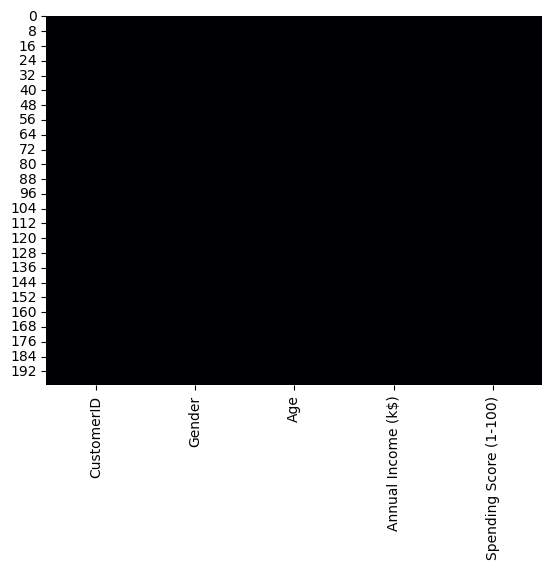

In [7]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

- ¡No hay **valores nulos** presentes en los datos!

In [44]:
print('Número de registros duplicados:', data.duplicated().sum())
data[data.duplicated()]

Número de registros duplicados: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


> No se encontraron registros duplicados.

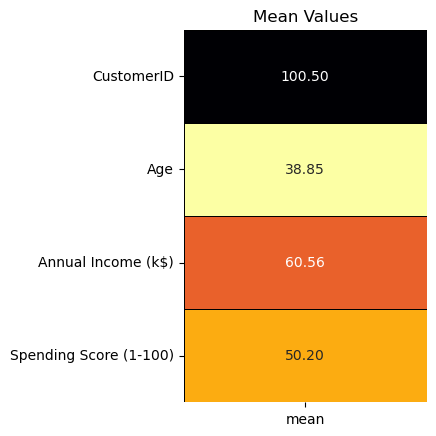

In [8]:
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))

plt.subplot(1,1,1)
sns.heatmap(data.describe().T[['mean']],cmap = 'inferno_r',annot = True,fmt = '.2f',linecolor = 'black',linewidths = 0.4,cbar = False);
plt.title('Mean Values');

fig.tight_layout(pad = 3)

- La **Age** (edad) promedio de los clientes en el dataset ronda finales de los 30, es decir, **38.85**. 
- El **Annual Income (k\$)** (ingreso anual) promedio de los clientes es de **60.56**, es decir, apenas por debajo del ingreso medio de 2018 de un ciudadano de EE. UU., 63k$.
- El promedio del **Spending Score (1-100)** (puntaje de gasto) del cliente del centro comercial está en el centro, con **50.20**.

# <center>Análisis Exploratorio de Datos</center>

### Dividiendo las características en Numéricas y Categóricas :

In [9]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Gender
Numerical Features : CustomerID Age Annual Income (k$) Spending Score (1-100)


- Aquí, las características categóricas se definen si el atributo tiene menos de 6 elementos únicos; de lo contrario, es una característica numérica.
- El enfoque típico para esta división de características también puede basarse en los tipos de datos de los elementos del atributo respectivo.

**Ej. :** tipo de dato = entero, atributo = característica numérica ; tipo de dato = cadena de texto, atributo = característica categórica

- Para este dataset, como el número de características es reducido, también podemos revisar el dataset manualmente.

> El criterio de "más de 6 valores únicos = numérica" parece un poco arbitrario, pero funciona bien porque `Gender` solo tiene 2 valores (`Male`/`Female`) y las demás columnas tienen decenas de valores distintos. Si el dataset tuviera, por ejemplo, una columna de "rango de edad" con 4 o 5 categorías, este mismo criterio también la habría tomado bien como categórica.

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Gender'] = le.fit_transform(df1['Gender'])

print('Label Encoder Transformation')
print(df1['Gender'].unique(),' = ',le.inverse_transform(df1['Gender'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


- Creando una copia profunda del dataset original y codificando (label encoding) el texto de **Gender**.
- Las modificaciones en el dataset original no se reflejarán en esta copia profunda.
- Por lo tanto, usamos esta copia profunda del dataset, que tiene **Gender** convertido en valores numéricos, para fines de visualización y modelado.

> Lo que hace *label encoding* es cambiar `Female`/`Male` por `0`/`1` para que se pueda tratar como número. Sirve tenerlo codificado para la matriz de correlación y para los boxplots/violinplots que vienen en el EDA.

### Distribución de las Características Categóricas y Numéricas :

C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\2039315377.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
c:\Users\DELL\anaconda3\Lib\site-packages\seaborn\distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\2039315377.py:11: UserWarning: 

`distplot` is a deprecated function and wil

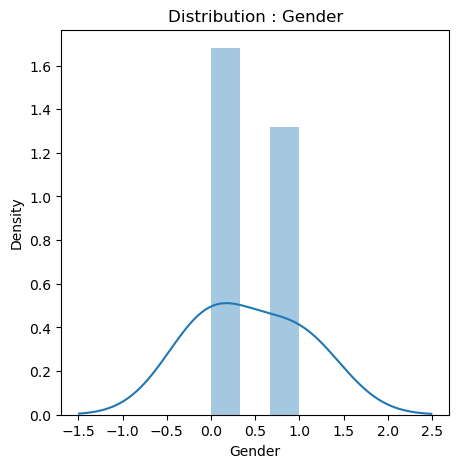

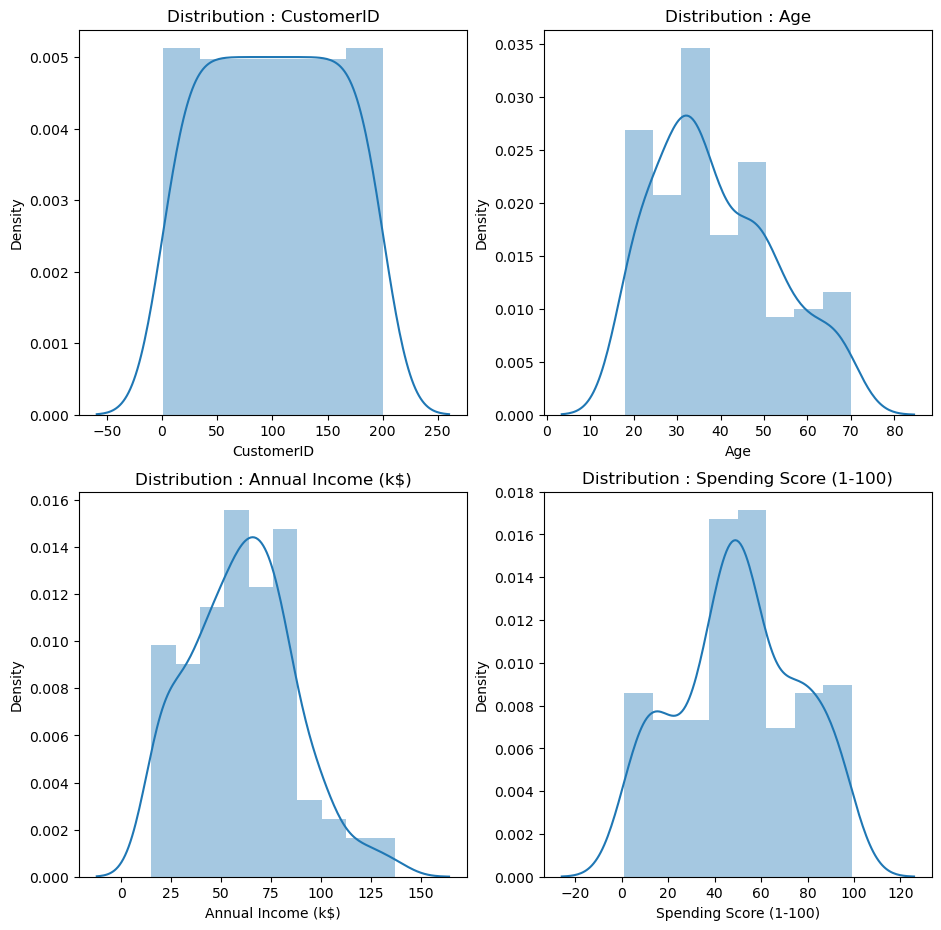

In [11]:
fig, ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))
for i in range(len(categorical_features)):
    plt.subplot(1,1,i+1)
    sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
    title = 'Distribution : ' + categorical_features[i]
    plt.title(title)
    
fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (11,11))
for i in range(len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.distplot(data[numerical_features[i]],)
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

- **Gender**, la única característica categórica, muestra una **distribución normal**.
- La distribución de **Age** y **Annual Income (k\$)** es **positivamente o sesgada a la derecha**.
- La distribución de datos de **Spending Score (1-100)** es similar al patrón **Cabeza y Hombros** observado en los gráficos bursátiles. 
- Muestra el precio de una acción subiendo hasta un pico y luego bajando de vuelta a la base del movimiento alcista previo. Se puede observar algo similar con los **2 hombros** formándose alrededor de los valores **20 y 80**, con la **cabeza** centrada entre **40 - 60**.
- Eliminaremos la característica **CustomerID**, ya que es solo un número asignado a un cliente.

> Es una forma curiosa de mostrar que hay bastante gente con puntaje muy bajo, bastante gente con puntaje muy alto, y la mayoría se amontona en medio.

In [12]:
numerical_features.remove('CustomerID')

### Características Categóricas :

C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\830555179.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female','Male'])


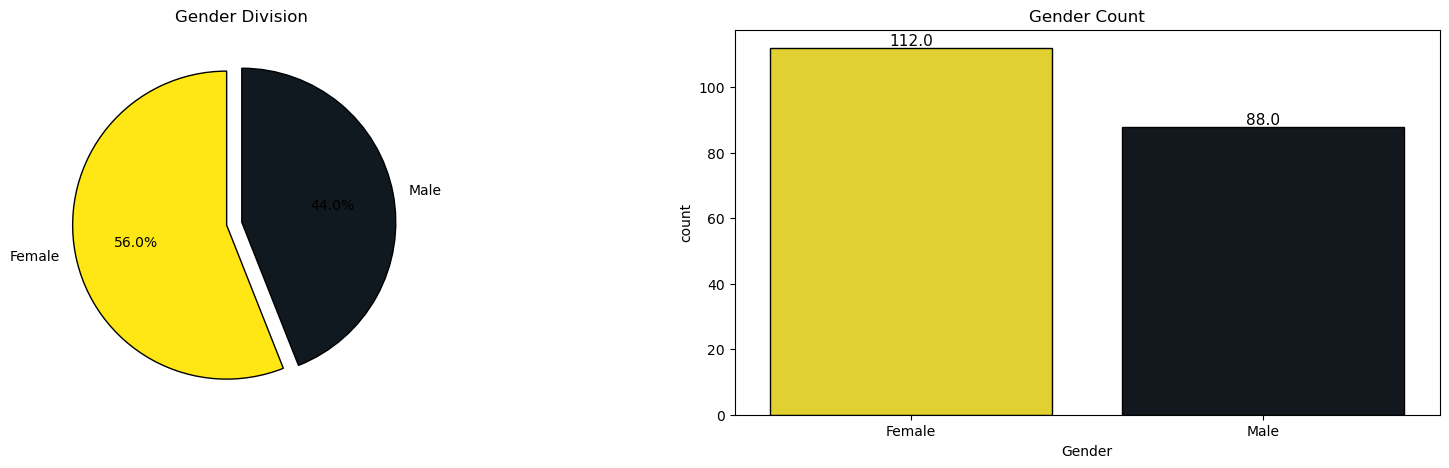

In [14]:
l = list(data['Gender'].value_counts())
circle = [l[0] / len(l) * 100, l[1] / len(l) * 100]
colors = ['#FEE715','#101820']

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (20,5))

plt.subplot(1,2,1)
plt.pie(circle,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Gender Division');

plt.subplot(1,2,2)
ax = sns.countplot(
    data=df1,
    x='Gender',
    hue='Gender',
    palette=colors,
    edgecolor='black',
    legend=False
)
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.75, rect.get_height(), horizontalalignment='center', fontsize = 11)
plt.title('Gender Count')
ax.set_xticklabels(['Female','Male'])

plt.show()

- Para el dataset anterior, las clientas **female** (mujeres) superan por poco a los clientes **male** (hombres). 

> La diferencia entre hombres y mujeres es mínima, prácticamente mitad y mitad con una ligerísima ventaja para las mujeres. No parece que vaya a cambiar mucho el análisis, pero está bien confirmarlo antes de seguir.

### Características Numéricas vs Características Categóricas :

C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\3178044531.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\3178044531.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female','Male'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\3178044531.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
C:\Users\DELL\AppData\Local\Temp\ipykernel_12048\3178044531.py:11: UserWarning: set_tickla

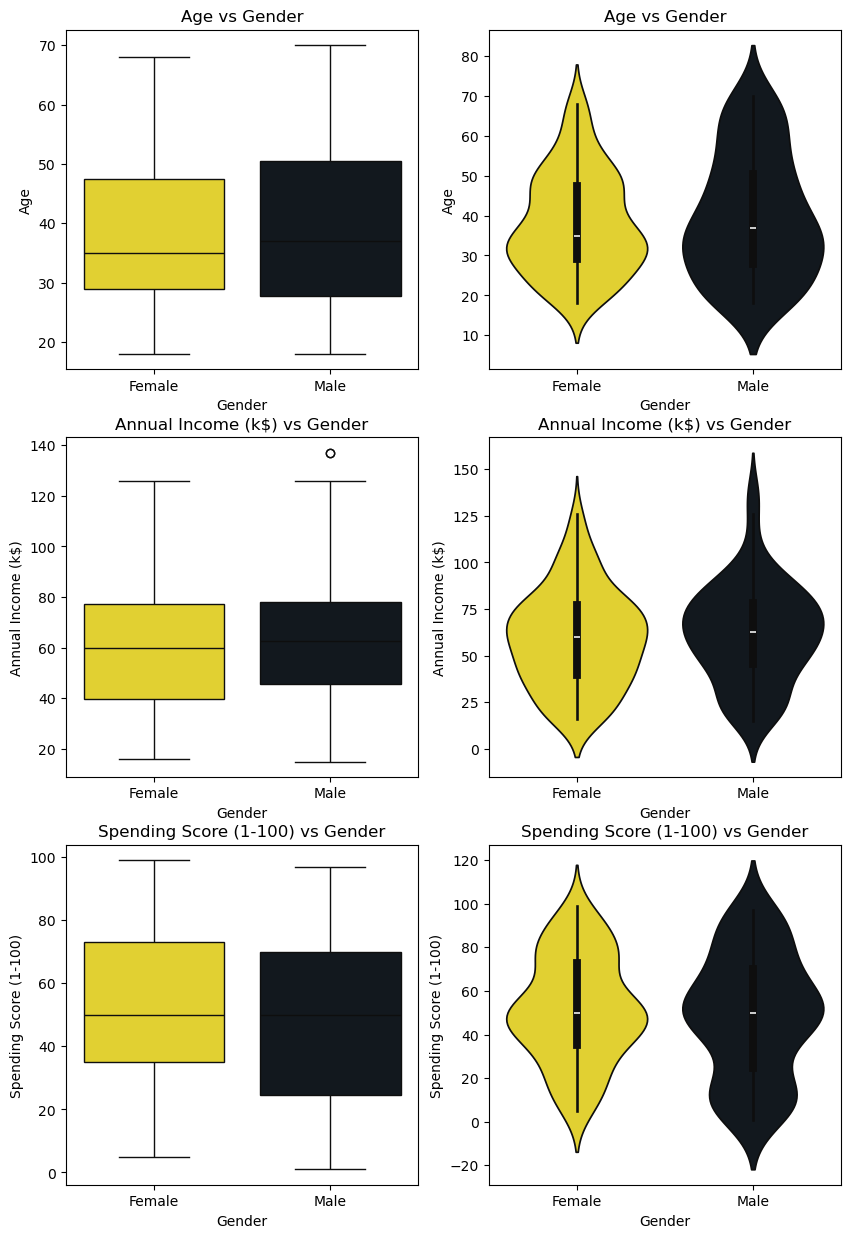

In [15]:
fig = plt.subplots(nrows = 3,ncols = 2,figsize = (10,15))
for i in range(len(numerical_features)):
    plt.subplot(3,2, (i * 2)  + 1)
    ax = sns.boxplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
    ax.set_xticklabels(['Female','Male'])
    title = numerical_features[i] + ' vs Gender'
    plt.title(title)
    
    plt.subplot(3,2,(i * 2) + 2)
    ax = sns.violinplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
    ax.set_xticklabels(['Female','Male'])
    title = numerical_features[i] + ' vs Gender'
    plt.title(title)

- El rango de **Age** de las clientas **female** va de **30 a justo por debajo de 50**, mientras que el rango de **Age** de los clientes **male** va de **justo por debajo de 30 a 50**. 
- Para ambos **Genders**, se puede observar un abultamiento en la edad de **30 - 35**. La **Age** mediana de **male** es ligeramente mayor que la de **female**.
- Para **Annual Income (k\$)**, el ingreso de las clientas **female** comienza desde **40k**, mientras que el de los clientes **male** está por encima de este valor. 
- El **Annual Income (k\$)** mediano para ambos **Genders** ronda los **60k**. El **Annual Income (k\$)** de los clientes **male** se estrecha muy bruscamente en la cima, con algunos valores atípicos en comparación con las clientas **female**.
- El **Spending Score (1-100)** mediano de ambos **Genders** es el mismo, a pesar de tener puntos de partida distintos: **justo por debajo de 40** y **justo por encima de 20** para las clientas **female** y los clientes **male**, respectivamente.
- Ambos **Genders** muestran un fuerte abultamiento en el valor mediano, especialmente las clientas **female**. Sin embargo, los clientes **male** también muestran un abultamiento pequeño pero significativo en el rango de **0 - 20**.

> Estas comparaciones por género no parecen aportan tanto para lo que se busca al final (clústeres por ingreso/edad/gasto), pero sirven para descartar que el género esté introduciendo algún sesgo. En general hombres y mujeres se comportan bastante parecido en ingreso y gasto, con diferencias menores en los rangos.

### Características Numéricas vs Características Numéricas respecto a la Característica Categórica :

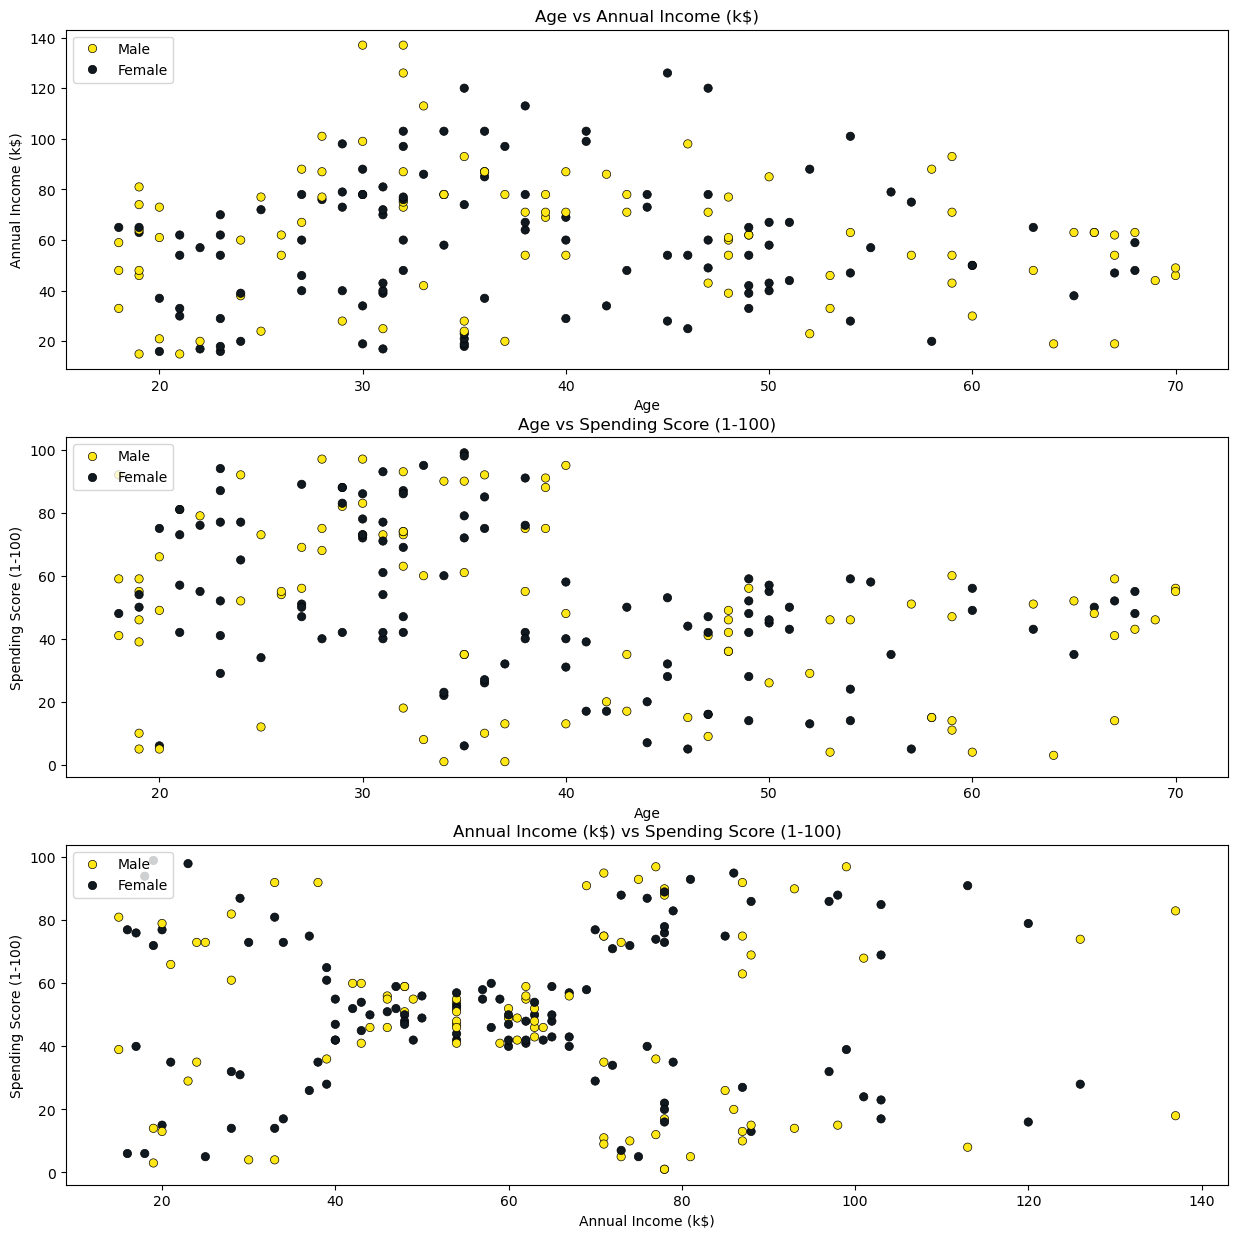

In [16]:
a = 0
fig,ax = plt.subplots(nrows = 3,ncols = 1,figsize = (15,15))
for i in range(len(numerical_features) - 1):
    for j in range(len(numerical_features)):
        if i != j and j > i:
            a += 1
            plt.subplot(3,1,a)
            sns.scatterplot(x = numerical_features[i],y = numerical_features[j],data = data,
                            hue = 'Gender',palette = colors,edgecolor = 'black');
            plt.legend(loc = 'upper left',)
            title = numerical_features[i] + ' vs ' + numerical_features[j]
            plt.title(title)

- Los puntos de datos de **Annual Income (k\$)** están presentes en todos los valores de **Age**; **Gender** no aporta información significativa. 
- Para **Spending Score (1-100)**, se puede observar claramente que el rango de **Age** de **20 - 30** muestra hábitos de gasto muy altos. 
- El grupo de **Age** de **30 - 40** resalta ambos extremos de los hábitos de gasto en el cliente. El grupo de **Age** de **40 - 70** muestra el otro extremo de los hábitos de gasto, con valores bajos.    
- A partir de **Annual Income (k\$) vs Spending Score (1-100)**, se pueden observar 5 grupos distintos. Para valores de **Annual Income (k\$)** entre **0 - 40**, los datos resaltan 2 grupos de clientes con **Spending Score (1-100)** entre **0 - 40** y **60 - 100**.
- Después de mostrar este primer extremo, los datos resaltan el grupo intermedio de clientes, que tiene un **Annual Income (k\$)** entre **40 - 70k** y un **Spending Score (1-100)** entre **40 - 60**.
- Los valores de **Annual Income (k\$)** entre **70 - 140k** definen el otro extremo, que se divide en 2 grupos según los valores de **Spending Score (1-100)** de **0 - 40** y **60 - 100**.

> 💬 Esta es de las gráficas más importantes de todo el EDA , porque ya se alcanza a ver a simple vista que en *Income vs Spending Score* hay como 5 nubes de puntos bien diferenciadas.

# <center>Resumen del EDA</center>

- Para los datos del centro comercial anteriores, las clientas **female** son más numerosas que los clientes **male**. Los datos de **Gender** están bastante distribuidos de manera uniforme respecto a las demás características.
- Los clientes del centro comercial pueden dividirse por sus grupos de **Age** : 
    - **20 - 30** 
    - **30 - 40**
    - **40 - 70**. 
- El **Annual Income (k\$)** mediano de ambos **genders** es de aproximadamente **60k**. Muestra 3 grupos de valores : 
    - **0 - 40k** 
    - **40 - 70k**
    - **70 - 140k**.
- El **Spending Score (1-100)** de **female** es mayor que el de los clientes **male**. También se pueden dividir los clientes en 3 grupos :
    - **0 - 40**
    - **40 - 60**
    - **60 - 100**
- Usando la combinación de los valores anteriores, los **Clientes del Centro Comercial** pueden segmentarse, logrando así una atención específica para cada uno. 

# <center>Ingeniería de Características</center>

### Matriz de Correlación :

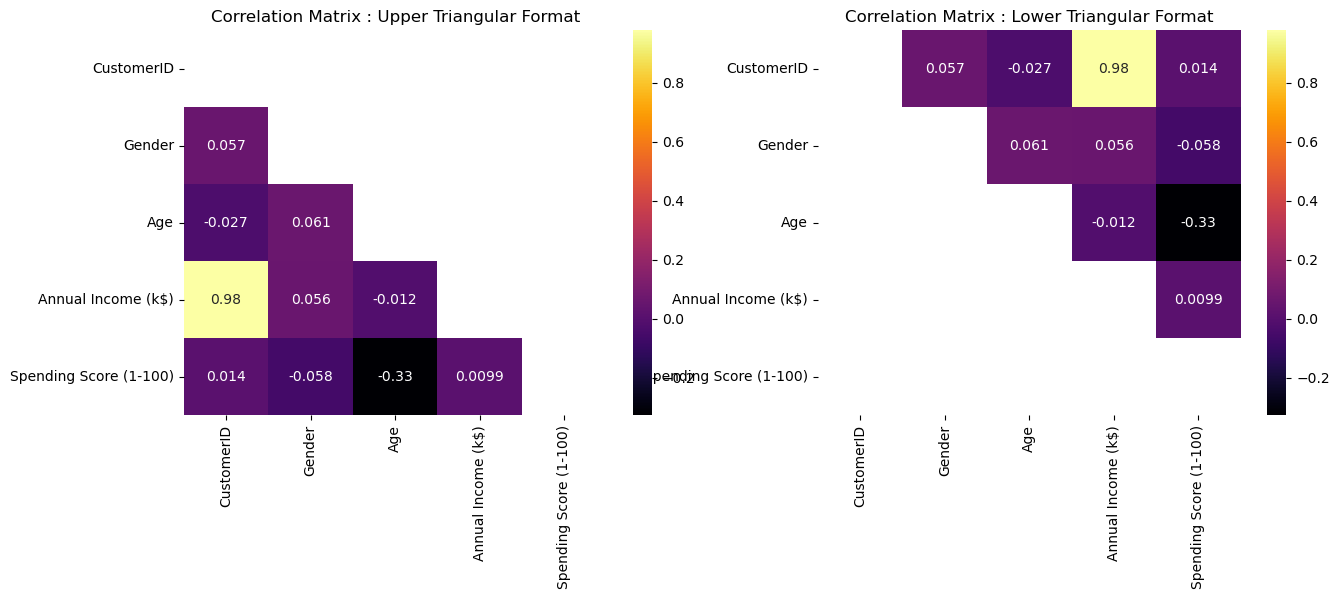

In [17]:
ut = np.triu(df1.corr())
lt = np.tril(df1.corr())

fig,ax = plt.subplots(nrows = 1, ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = ut);
plt.title('Correlation Matrix : Upper Triangular Format');

plt.subplot(1,2,2)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = lt);
plt.title('Correlation Matrix : Lower Triangular Format');

df1.drop(columns = 'CustomerID',inplace = True)

- ¡Ambas matrices mostradas son iguales! Solo se hace por motivos de visualización. Este truco se puede usar cuando el dataset tiene demasiadas características para revisar. 
- **CustomerID** muestra una correlación positiva muy alta con **Annual Income (k\$)**, ya que los clientes están ordenados de forma ascendente según su **Annual Income (k\$)**. No incluiremos **CustomerID** para fines de modelado.
- **Gender** no muestra ninguna relación con las demás características. Es bastante neutral, con todos los valores cercanos a 0.
- **Spending Score (1-100)** y **Age** muestran una correlación negativa, es decir, si el valor de una característica aumenta, el valor de la otra disminuye, ¡y viceversa!
- Esta información se obtuvo en la sección de **EDA**; los valores de la matriz de correlación refuerzan aún más esta evidencia. 
- Ahora pasaremos a la sección de modelado, creando combinaciones de estas características y buscando distintas formas en que los clientes del centro comercial pueden segmentarse.

> La correlación negativa entre `Age` y `Spending Score` coincide con lo que se ve en las gráficas de dispersión: la gente más joven tiende a gastar más y la gente mayor gasta menos. 

### Escalado de Datos :

- El modelo de machine learning no entiende las unidades de los valores de las características. Trata la entrada simplemente como un número, pero no comprende el verdadero significado de ese valor. Por lo tanto, es necesario escalar los datos.

- Tenemos 2 opciones para el escalado de datos : 
    
    1) **Normalización** 
    
    2) **Estandarización**. 


- Como la mayoría de los algoritmos asumen que los datos tienen una distribución normal (Gaussiana), se aplica **Normalización** a las características que no muestran una distribución normal, y se aplica **estandarización** a las características que sí son normalmente distribuidas, pero cuyo rango de valores es muy grande o pequeño en comparación con otras características.

- Para el dataset anterior, hemos aplicado **Normalización** a 3 características : **Age**, **Annual Income (k\$)** y **Spending Score (1-100)**. La característica **Gender** se deja sin modificar.

In [18]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

# Label Encoding 
df2 = df1.copy(deep = True)

# Normalization
df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']])

- Para resaltar la diferencia entre el rendimiento de los modelos entrenados con el dataset original y con el dataset normalizado, creamos una copia del dataset original y le aplicamos la transformación de normalización.

**¡Ahora pasaremos a la sección de modelado!**

> Aquí se usa `MinMaxScaler`, que deja todos los valores entre 0 y 1. La diferencia con `StandardScaler` es que ese último centra los datos en 0 con desviación estándar 1, en vez de acotarlos a un rango fijo. 

# <center>Modelado</center>

- **Aprendizaje No Supervisado** : Es un problema donde se desconoce la variable / característica objetivo. Los problemas de **Aprendizaje No Supervisado** ocurren ampliamente en el ámbito médico, donde se toman múltiples mediciones y se desconocen las enfermedades subyacentes. 
- Por lo tanto, buscar patrones mediante técnicas de visualización nos brinda información subyacente que no se puede comprender simplemente observando los datos tabulares.
- Sin embargo, cuando el tamaño de los datasets se vuelve enorme, con demasiadas características, la visualización de datos puede convertirse en una tarea tediosa. Por eso recurrimos al algoritmo de **K-Means Clustering**, el cual **no admite características categóricas**. 
- Es el algoritmo más preferido para tratar el **Aprendizaje No Supervisado**, ya que se encarga de encontrar clústeres / grupos en los datos mediante un enfoque matemático :
    - Selecciona 2 (suponiendo k = 2) centroides de forma aleatoria.
    - Se calcula la distancia entre los centroides y todos los puntos de datos.
    - Si el punto de datos está más cerca de uno de los centroides, se le asigna la etiqueta de ese centroide, y viceversa.
    - Para los 2 clústeres formados, se calcula el valor promedio de los puntos de datos agrupados con cada centroide, y estos valores promedio se definen entonces como los nuevos clústeres.
    - Este proceso se repite hasta que ambos centroides convergen en puntos fijos.
- **Hiperparámetro k** : Define el número de clústeres o grupos en los que se dividirán los datos. Para la selección de los valores de **k**, usamos 2 pruebas estadísticas :
    - **Método del Codo (Elbow Method)** : Es un método que grafica la suma de errores al cuadrado para un rango de valores de **k**. Si esta gráfica se parece a un brazo, se selecciona el valor de **k** que se asemeja a un **codo**. A partir de este valor de **codo**, la suma de valores al cuadrado (inercia) comienza a disminuir de manera lineal, por lo que se considera un valor óptimo.
    - **Método del Puntaje de Silueta (Silhouette Score)** : Es un método que evalúa la calidad de los clústeres en función de qué tan bien están agrupados los puntos de datos con otros puntos de datos similares entre sí. Este puntaje se calcula usando la fórmula de distancia, y se selecciona el valor de **k** con el puntaje más alto para el modelado.
    
**Ahora crearemos modelos entrenándolos con la combinación de características seleccionadas a partir de las pruebas anteriores, y también las visualizaremos.**

In [19]:
# Dropping categorical feature 
df1.drop(columns = 'Gender',inplace = True)
df2.drop(columns = 'Gender',inplace = True)

> Para el modelado se retiro `Gender` de ambos datasets: K-Means trabaja con distancias, y no tiene mucho sentido introducir una variable categórica codificada como 0/1 junto con variables numéricas de escalas tan distintas.

### <center>Age - Annual Income (k\$)</center>

In [20]:
m1 = df1[['Age','Annual Income (k$)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)']].values # Normalized Dataset

> Aquí se armo los arreglos con las columnas de esta primera combinación (`Age` e `Annual Income`): `m1` con los datos originales y `m2` con los normalizados. Este mismo patrón (armar `m1`/`m2`, sacar codo + silueta, entrenar, graficar) se repite para cada combinación de variables que se prueba más abajo.

### Dataset Original :

#### Método del Codo y Método del Puntaje de Silueta :

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

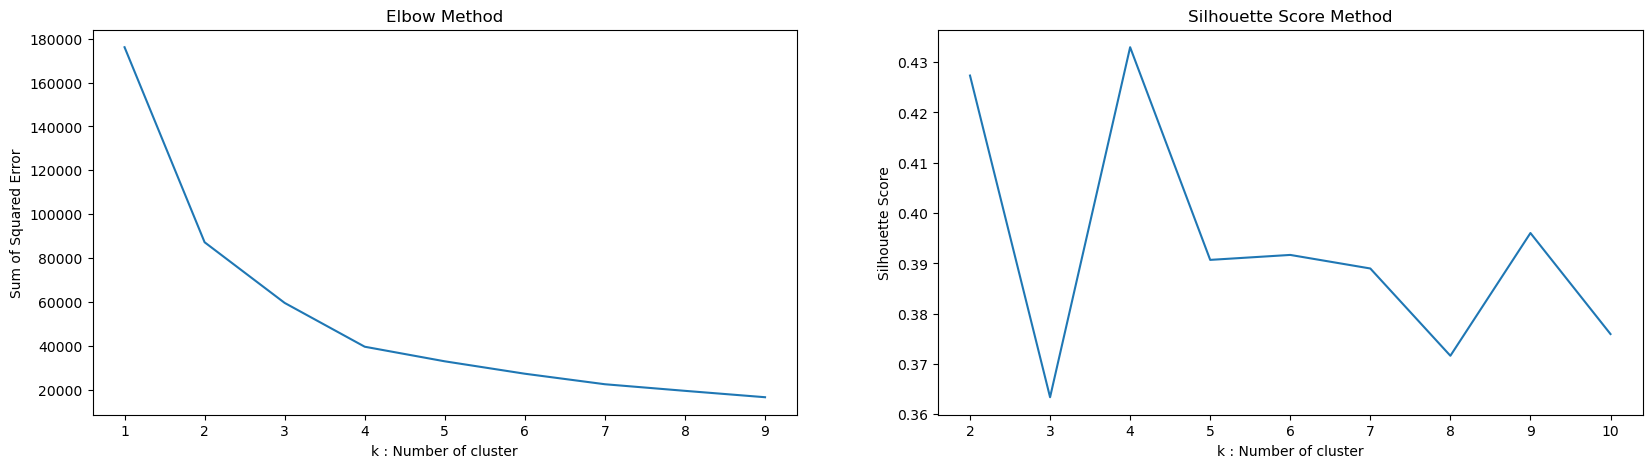

In [21]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

> En la gráfica del codo cuesta un poco ver el quiebre exacto, pero se empieza a aplanar entre k=3 y k=5. La de silueta ayuda a decidir mejor.

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 4**

Número de clústeres (k): 4
Inercia (WCSS): 109997.09
Iteraciones realizadas: 5
Parámetros del modelo: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 1000, 'n_clusters': 4, 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


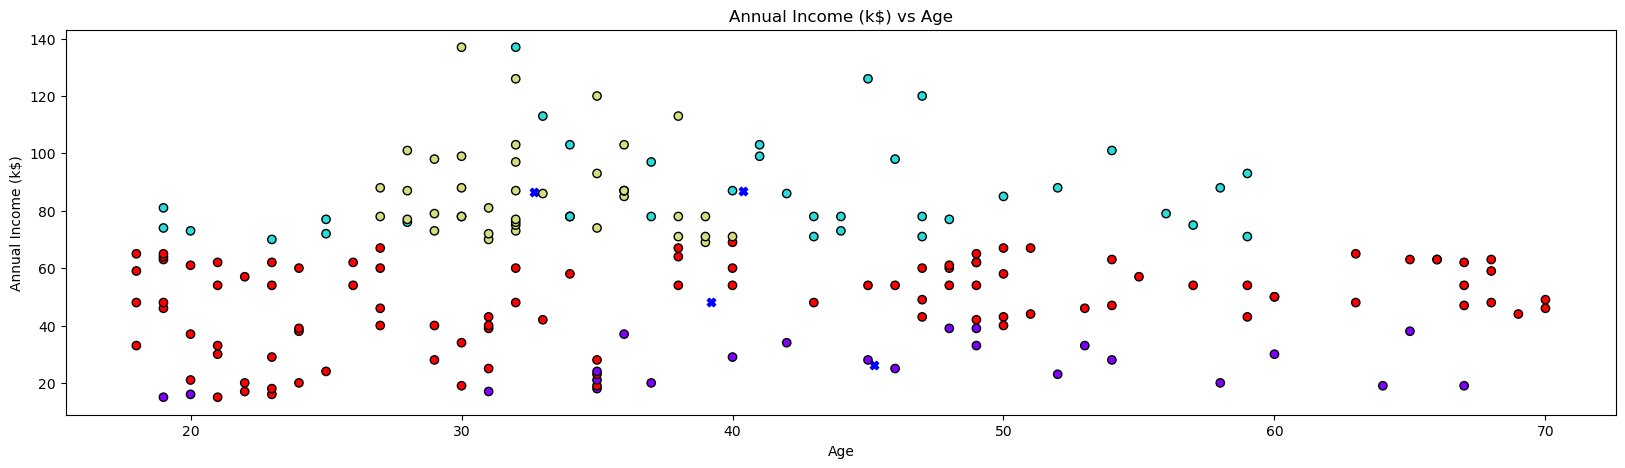

In [45]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)

print(f'Número de clústeres (k): {model.n_clusters}')
print(f'Inercia (WCSS): {model.inertia_:.2f}')
print(f'Iteraciones realizadas: {model.n_iter_}')
print(f'Parámetros del modelo: {model.get_params()}')

cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

> Se ven los 4 grupos, aquí se traslapan un poco en los bordes, seguramente porque la edad no tiene una relación tan directa con el ingreso.

### Dataset Normalizado :

#### Método del Codo y Método del Puntaje de Silueta :

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

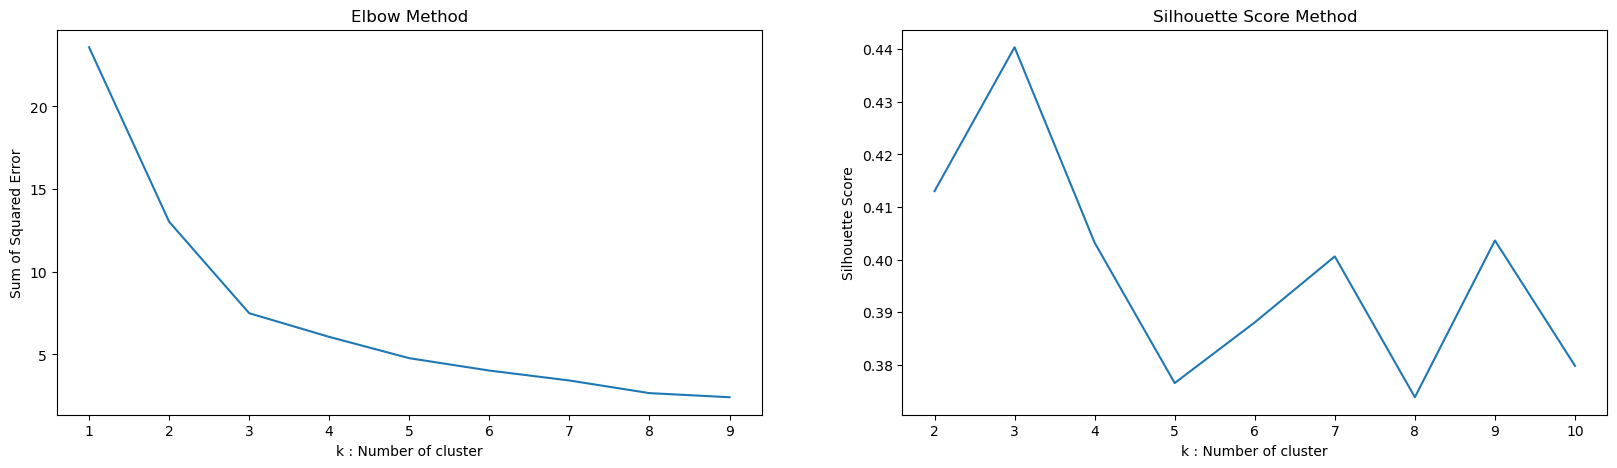

In [23]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

> Con los datos normalizados el codo y la silueta ya no sugieren lo mismo que con los originales, esta vez apuntan más hacia k=3. Es justo el efecto de la normalización: al dejar todas las variables en la misma escala, ninguna "pesa" más que otra por sus unidades, y el número óptimo de clústeres puede cambiar.

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 3**

Número de clústeres (k): 3
Inercia (WCSS): 17.54
Iteraciones realizadas: 4
Parámetros del modelo: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 1000, 'n_clusters': 3, 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


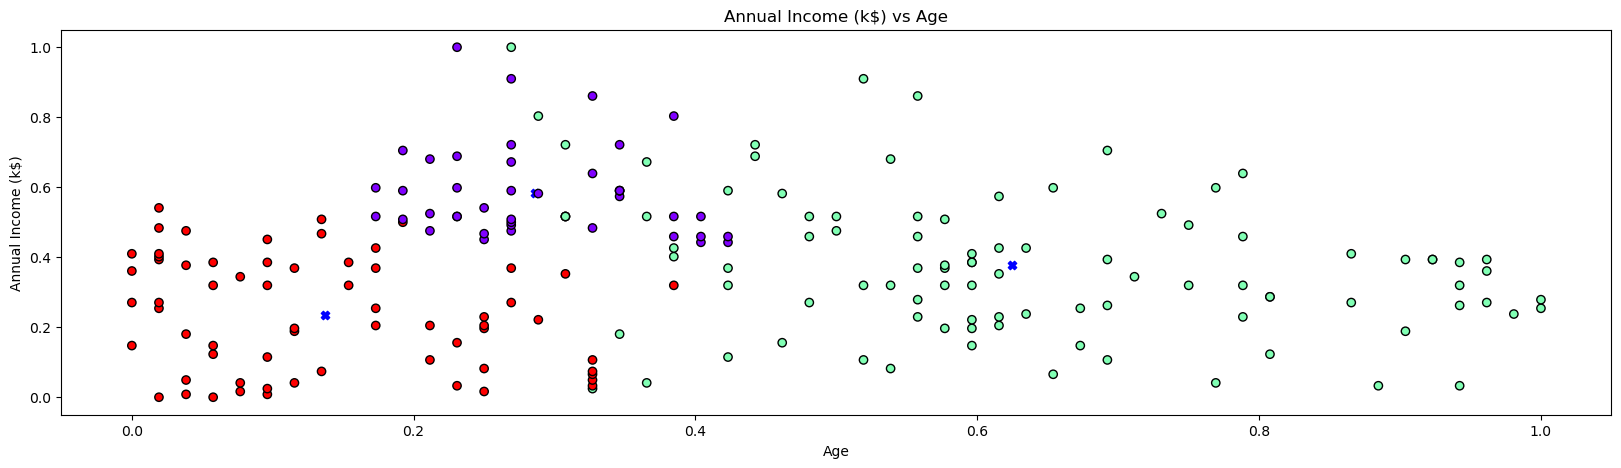

In [46]:
model = KMeans(n_clusters = 3,max_iter = 1000)
model.fit(m2)

print(f'Número de clústeres (k): {model.n_clusters}')
print(f'Inercia (WCSS): {model.inertia_:.2f}')
print(f'Iteraciones realizadas: {model.n_iter_}')
print(f'Parámetros del modelo: {model.get_params()}')

cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Annual Income (k$)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

> Con 3 clústeres en vez de 4 los grupos se ven un poco más simples de interpretar, pero también se pierde algo de detalle. Es el trade-off típico de bajarle a k: grupos más generales, menos matices.

### <center>Age - Spending Score (1-100)</center>

In [25]:
m1 = df1[['Age','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Spending Score (1-100)']].values # Normalized Dataset

> Mismo patrón que la combinación anterior, solo que ahora cruzo `Age` con `Spending Score` en vez de con `Annual Income`.

### Dataset Original :

#### Método del Codo y Método del Puntaje de Silueta :

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

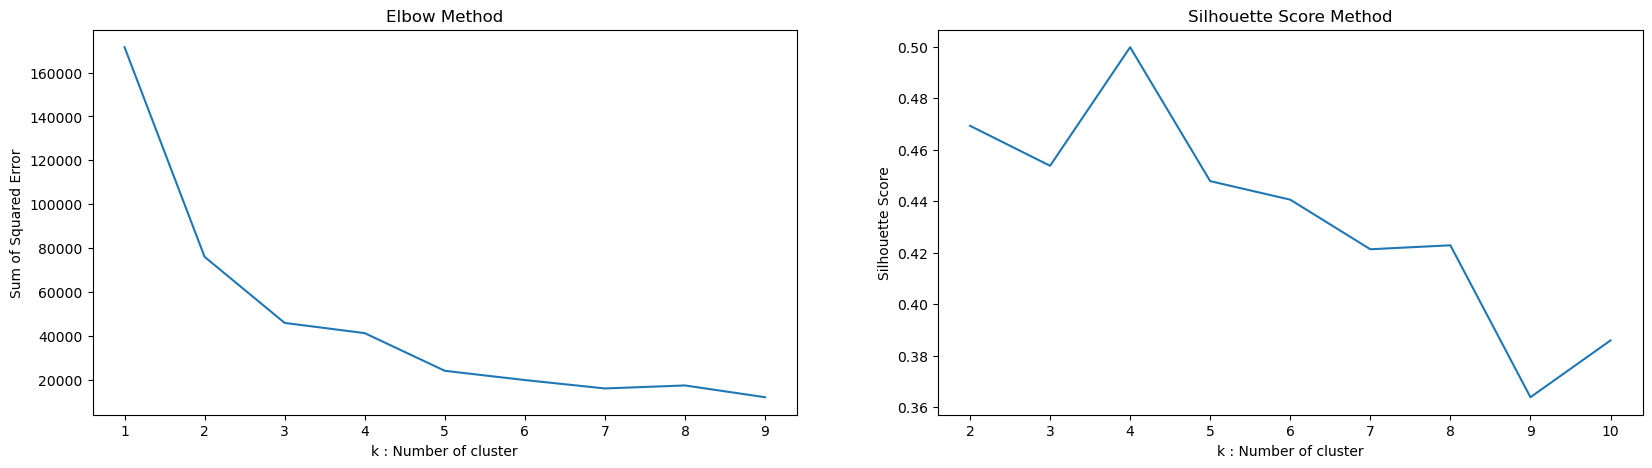

In [26]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

> Otra vez el codo no es muy claro, pero la silueta sí apoya que k=4 es una buena opción aquí también.

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 4**

Número de clústeres (k): 4
Inercia (WCSS): 104374.16
Iteraciones realizadas: 6
Parámetros del modelo: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 1000, 'n_clusters': 4, 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


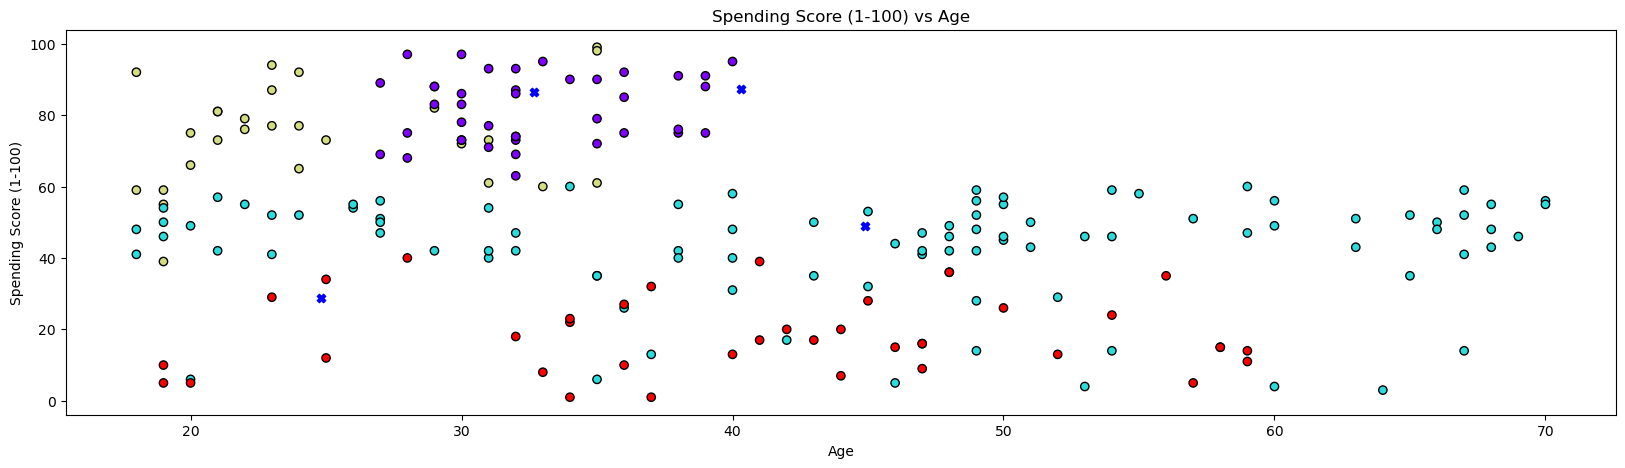

In [48]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)

print(f'Número de clústeres (k): {model.n_clusters}')
print(f'Inercia (WCSS): {model.inertia_:.2f}')
print(f'Iteraciones realizadas: {model.n_iter_}')
print(f'Parámetros del modelo: {model.get_params()}')

cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

> Se nota bastante el patrón que ya se habia visto en el scatterplot del EDA: los clientes jóvenes con *Spending Score* alto forman su propio grupo bien definido. En general la edad sí ayuda a separar comportamientos de gasto, aunque no tan limpio como con el ingreso.

### Dataset Normalizado :

#### Método del Codo y Método del Puntaje de Silueta :

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

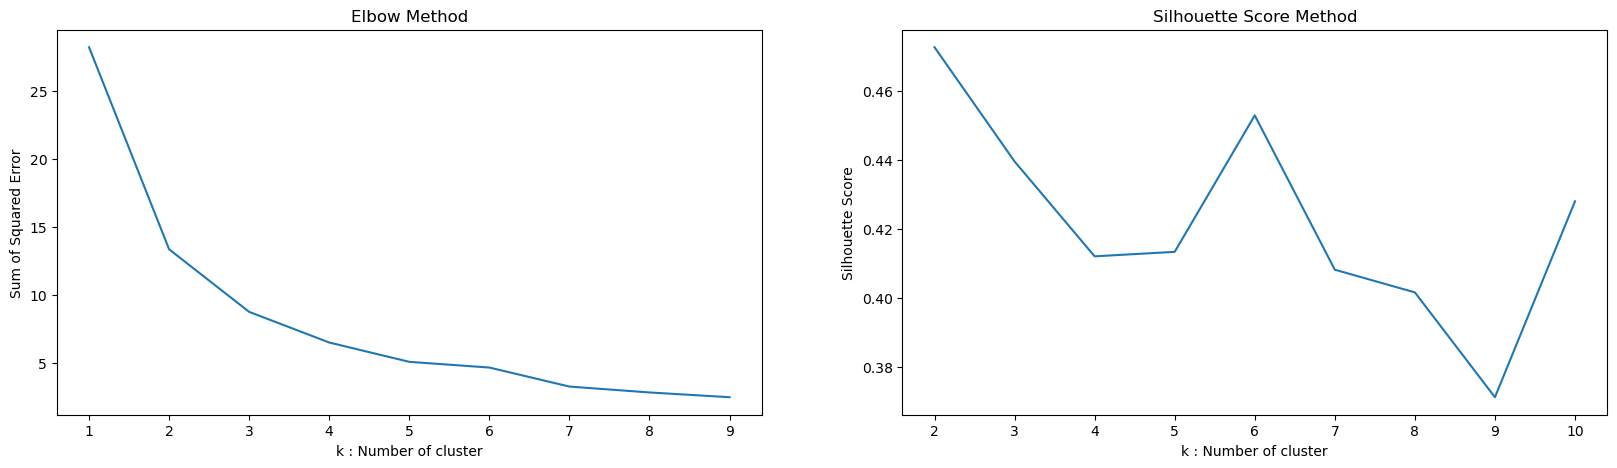

In [28]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

> Aquí sí cambia bastante el resultado: normalizado, el número sugerido sube a k=6. Puede que al normalizar se vuelvan "visibles" subgrupos que antes quedaban ocultos por la diferencia de escalas entre `Age` y `Spending Score`.

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 6**

Número de clústeres (k): 6
Inercia (WCSS): 8.44
Iteraciones realizadas: 6
Parámetros del modelo: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 1000, 'n_clusters': 6, 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


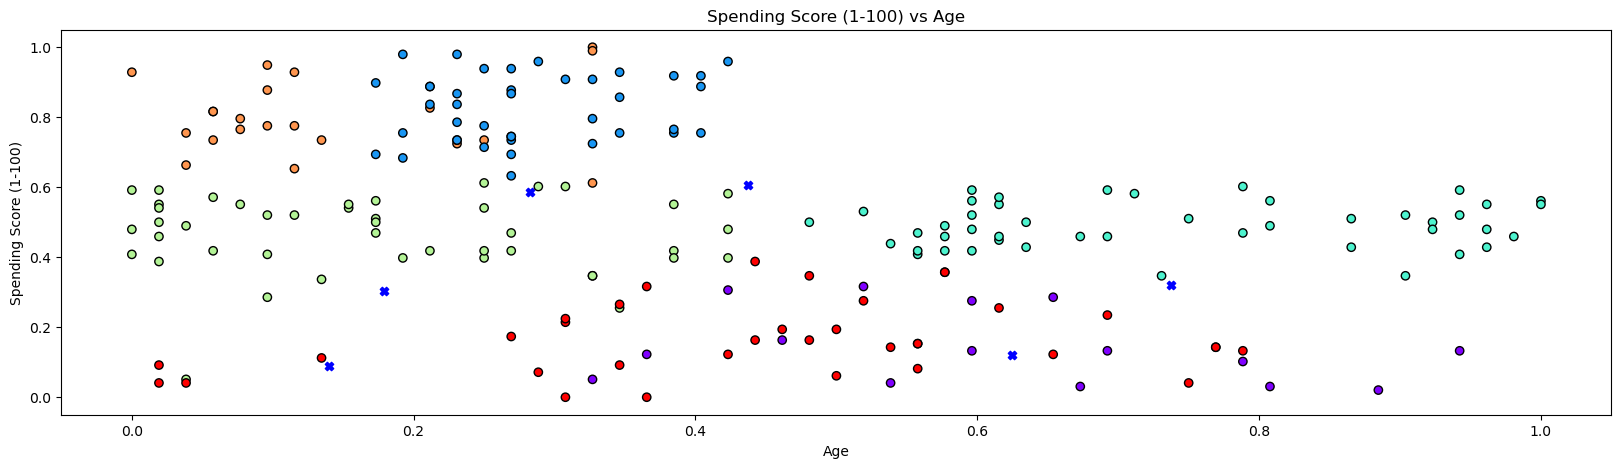

In [49]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)

print(f'Número de clústeres (k): {model.n_clusters}')
print(f'Inercia (WCSS): {model.inertia_:.2f}')
print(f'Iteraciones realizadas: {model.n_iter_}')
print(f'Parámetros del modelo: {model.get_params()}')

cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

> Con 6 clústeres ya se empieza a sentir un poco lo de sobre-segmentar: hay grupos que visualmente parecen casi el mismo bloque de puntos, solo divididos por una línea imaginaria que traza el algoritmo.

### <center>Annual Income (k\$) - Spending Score (1-100)</center>

In [30]:
m1 = df1[['Annual Income (k$)', 'Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Annual Income (k$)', 'Spending Score (1-100)']].values # Normalized Dataset

### Dataset Original :

#### Método del Codo y Método del Puntaje de Silueta :

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

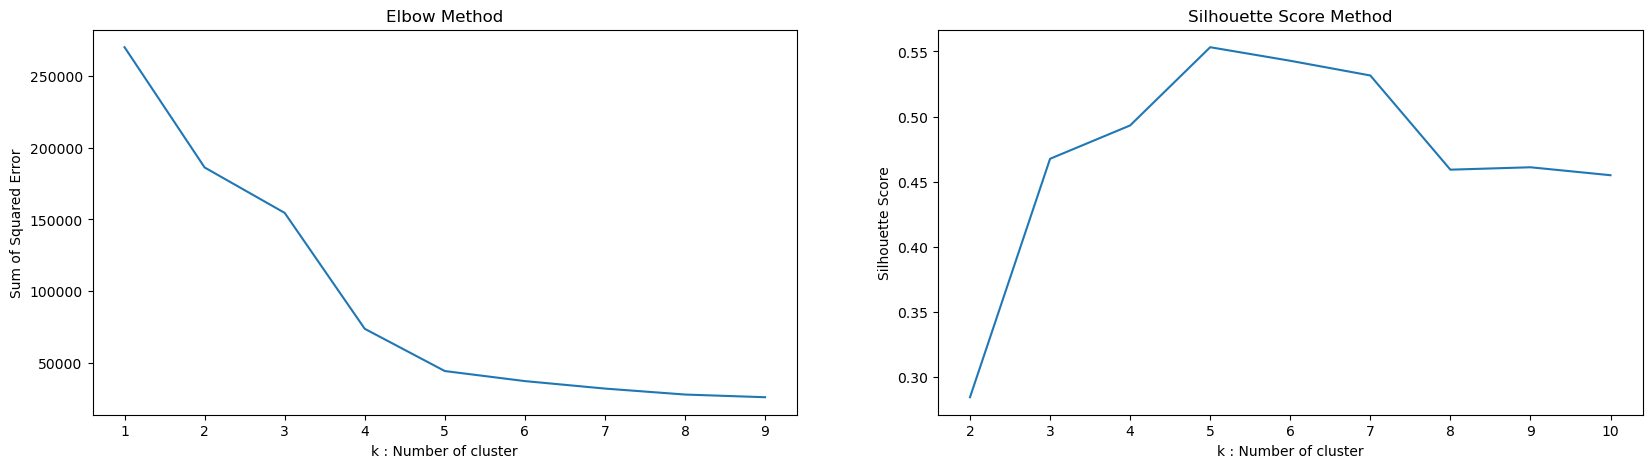

In [31]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

> Tanto el codo como la silueta apuntan bastante a k=5.

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 5**

Número de clústeres (k): 5
Inercia (WCSS): 99114.70
Iteraciones realizadas: 5
Parámetros del modelo: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 1000, 'n_clusters': 5, 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


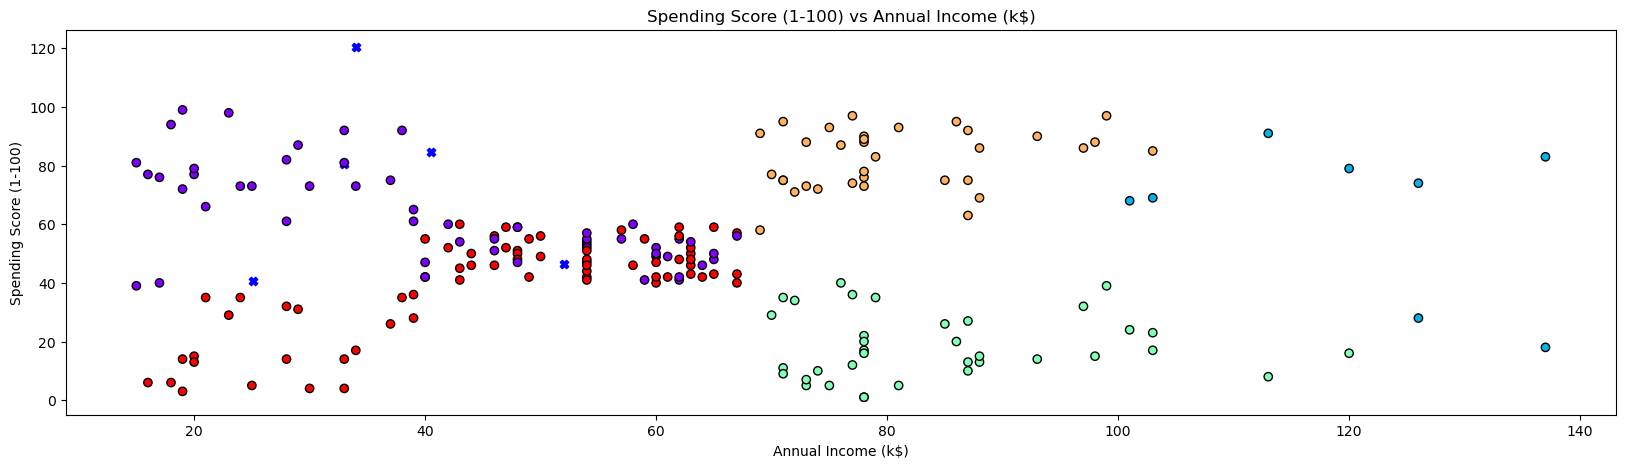

In [50]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m1)

print(f'Número de clústeres (k): {model.n_clusters}')
print(f'Inercia (WCSS): {model.inertia_:.2f}')
print(f'Iteraciones realizadas: {model.n_iter_}')
print(f'Parámetros del modelo: {model.get_params()}')

cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df1,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

> Los 5 grupos quedan claros y separados: ingreso bajo/gasto bajo, ingreso bajo/gasto alto, el grupo "promedio" en medio, ingreso alto/gasto bajo, e ingreso alto/gasto alto. Tiene sentido que sea la más limpia, porque son justo las 2 variables que un negocio como un centro comercial más querría cruzar para tomar decisiones de marketing.

### Dataset Normalizado :

#### Método del Codo y Método del Puntaje de Silueta :

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

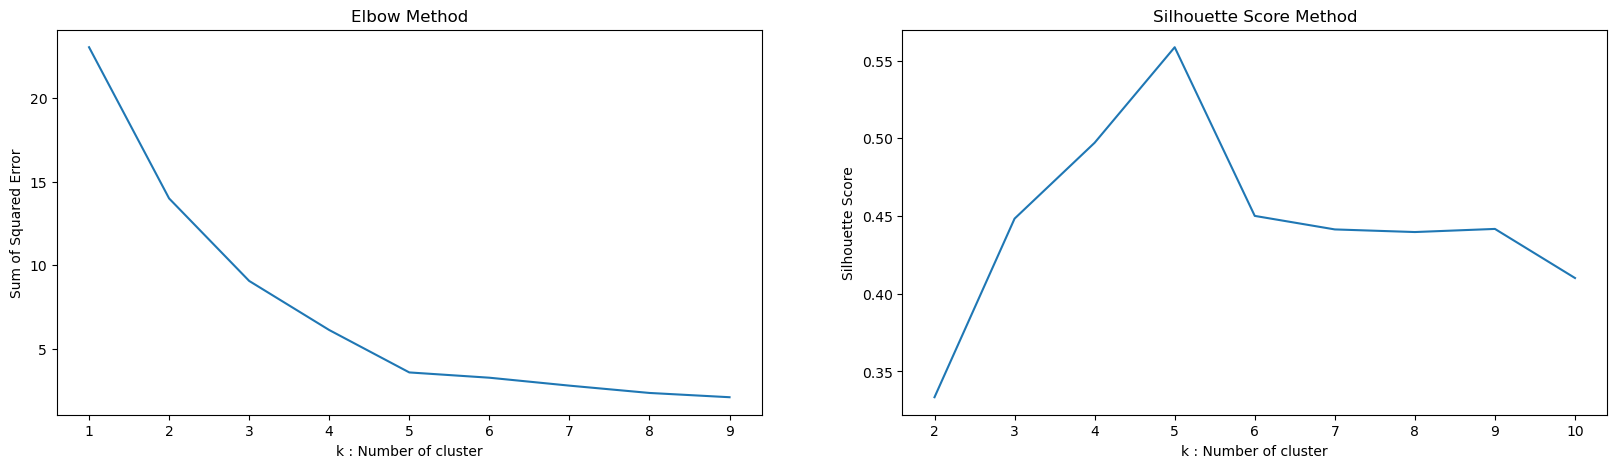

In [33]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 5**

Número de clústeres (k): 5
Inercia (WCSS): 10.30
Iteraciones realizadas: 7
Parámetros del modelo: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 1000, 'n_clusters': 5, 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


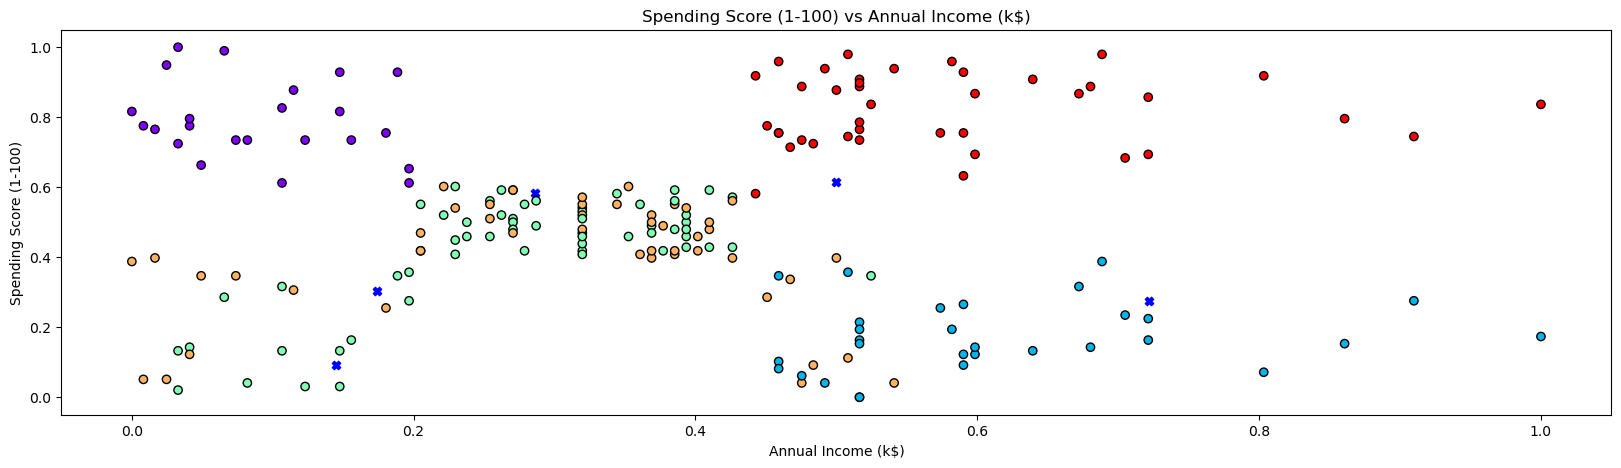

In [51]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m2)

print(f'Número de clústeres (k): {model.n_clusters}')
print(f'Inercia (WCSS): {model.inertia_:.2f}')
print(f'Iteraciones realizadas: {model.n_iter_}')
print(f'Parámetros del modelo: {model.get_params()}')

cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

> El resultado se ve prácticamente igual que con los datos originales, solo que ahora los ejes están en escala 0-1 en vez de en las unidades originales. Buena señal de que esta combinación de variables es robusta y no depende tanto de si escalo o no.

### <center>Age - Annual Income (k\$) - Spending Score (1-100)</center>

In [35]:
m1 = df1[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Normalized Dataset

> Ahora se ingresan las 3 variables juntas (`Age`, `Annual Income` y `Spending Score`) para ver qué tan bien se comporta K-Means en 3D, usando algo ma que solo con pares de variables.

### Dataset Original :

#### Método del Codo y Método del Puntaje de Silueta :

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

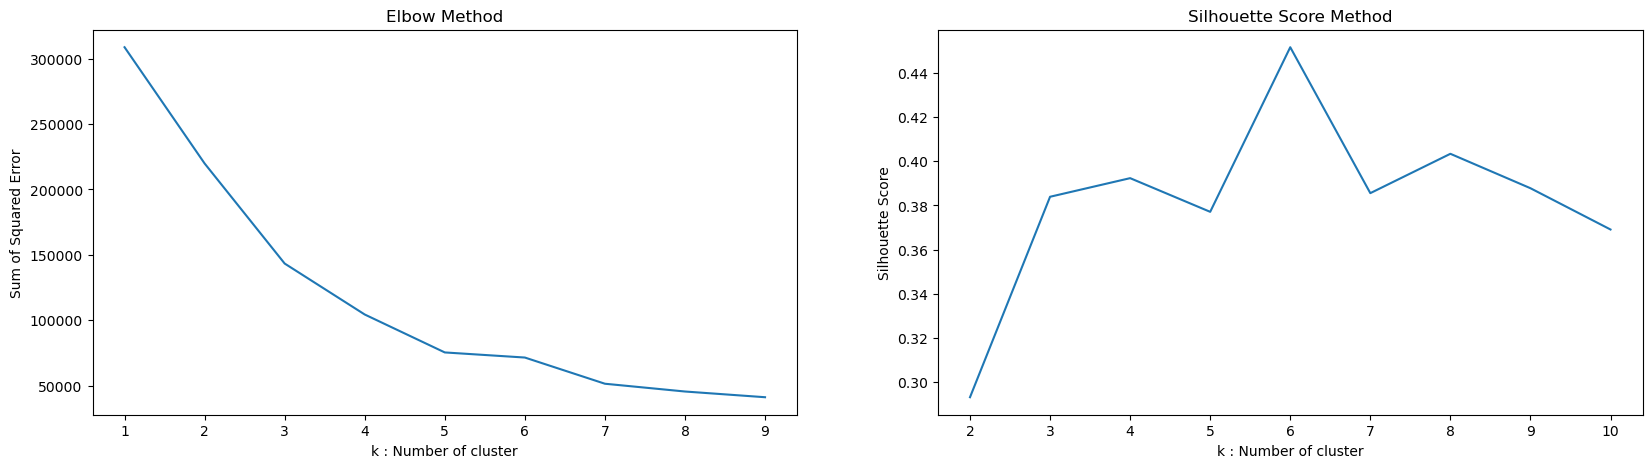

In [36]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

> Para las 3 variables juntas, el codo y la silueta sugieren k=6. Con 3 dimensiones ya se vuelve más difícil interpretar la gráfica a simple vista.

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 6**

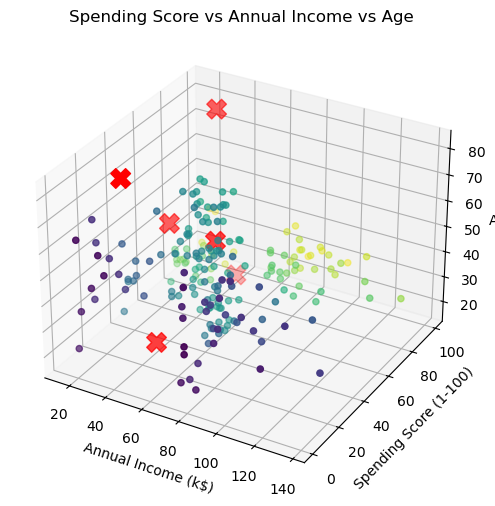

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c=y, cmap='viridis')

ax.scatter(
    centroids[:,0],
    centroids[:,1],
    centroids[:,2],
    marker='X',
    s=200,
    c='red'
)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')

plt.title('Spending Score vs Annual Income vs Age')
plt.show()

In [38]:
print(m1.shape)

print(centroids.shape)

print(x.shape)
print(y.shape)
print(z.shape)

print(df1.head())

(200, 3)
(6, 3)
(200,)
(200,)
(200,)
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40


### Dataset Normalizado

#### Método del Codo y Método del Puntaje de Silueta :

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

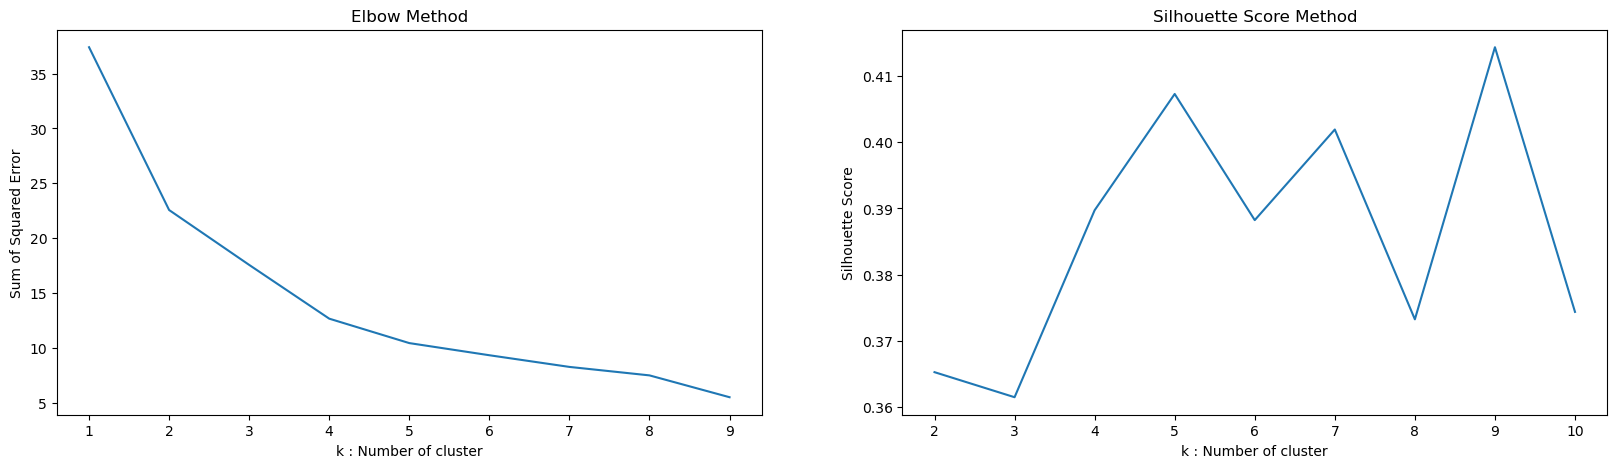

In [40]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

> 💬 Con los datos normalizados el resultado no cambia, sigue dando k=6 igual que con los datos originales.

- A partir de los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 6**

Número de clústeres (k): 6
Inercia (WCSS): 9.16
Iteraciones realizadas: 4
Parámetros del modelo: {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 1000, 'n_clusters': 6, 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


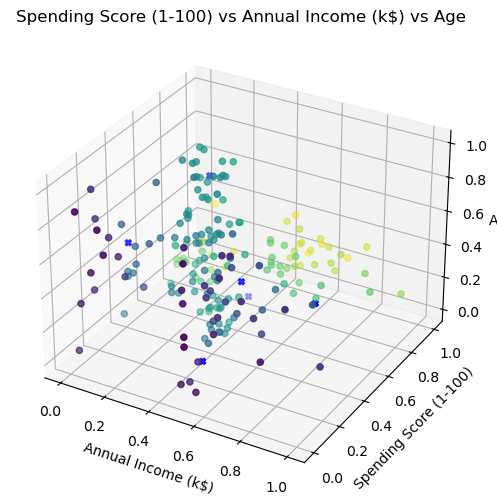

In [52]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)

print(f'Número de clústeres (k): {model.n_clusters}')
print(f'Inercia (WCSS): {model.inertia_:.2f}')
print(f'Iteraciones realizadas: {model.n_iter_}')
print(f'Parámetros del modelo: {model.get_params()}')

cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
x = np.array(df2['Annual Income (k$)'])
y = np.array(df2['Spending Score (1-100)'])
z = np.array(df2['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker = "X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

> Con 3 variables y 6 clústeres ya es bastante difícil distinguir los grupos solo viendo la gráfica, se empiezan a encimar visualmente aunque el algoritmo sí los separe bien matemáticamente por dentro. 

### <center>Tabla de Resultados</center>

#### Dataset Original :

|N.°|Combinación de Características|Número de Clústeres|
|-|-|-|
|1.|Age - Annual Income (k\$)|4|
|2.|Age - Spending Score (1-100)|4|
|3.|Annual Income (k\$) - Spending Score (1-100)|5|
|4.|Age - Annual Income (k\$) - Spending Score (1-100)|6|

#### Dataset Normalizado :

|N.°|Combinación de Características|Número de Clústeres|
|-|-|-|
|1.|Age - Annual Income (k\$)|3|
|2.|Age - Spending Score (1-100)|6|
|3.|Annual Income (k\$) - Spending Score (1-100)|5|
|4.|Age - Annual Income (k\$) - Spending Score (1-100)|6|

> Lo que más se repite es que el número de clústeres cambia entre datos originales y normalizados en casi todas las combinaciones, menos en *Income vs Spending Score*, que se mantiene en 5 pase lo que pase. Eso refuerza la idea de que esa es la combinación de variables más "estable" y confiable para segmentar clientes de este dataset.

### Mi Conclusión 

En conclusión, el uso del algoritmo **K-Means** permitió identificar diferentes perfiles de clientes del centro comercial a partir de variables como la **edad, el ingreso anual y el nivel de gasto**. Los resultados muestran grupos con características diferenciadas, principalmente entre clientes con ingresos altos o bajos y con niveles de gasto altos o bajos, lo que permite reconocer segmentos que podrían recibir estrategias de atención específicas.

Al comparar los datos originales con los **datos normalizados**, se observa la importancia de escalar las variables antes de aplicar K-Means, ya que las diferencias en sus rangos pueden influir en la formación de los clústeres. La normalización permite que las características tengan una participación más equilibrada en el cálculo de las distancias.

Asimismo, la cantidad de clústeres modifica la forma en que se dividen los clientes. Al utilizar diferentes valores de **k**, los grupos pueden ser más generales o más específicos; por ello, el método del codo y el **Silhouette Score** resultan útiles para seleccionar una cantidad adecuada de clústeres. En el notebook se trabajó con diferentes cantidades según las combinaciones de variables analizadas, destacando configuraciones de **4, 5 y 6 clústeres**.

Finalmente, K-Means presenta algunas limitaciones, ya que requiere definir previamente el número de clústeres y su funcionamiento depende de las distancias entre los datos. Además, los resultados pueden verse afectados por la escala de las variables y por la distribución del conjunto de datos. En este caso, el análisis se basa únicamente en un número reducido de características, por lo que los perfiles obtenidos representan una segmentación inicial de los clientes y no necesariamente consideran todos los factores que podrían influir en su comportamiento.


# <center>Conclusión</center>

- Este dataset es excelente para entender cómo abordar problemas de aprendizaje no supervisado. Presenta la oportunidad de trabajar en un Problema de Negocio que puede utilizarse para crear diversas estrategias para impulsar las ventas. 


- Para los problemas de aprendizaje no supervisado, el EDA resulta muy valioso para descubrir hallazgos ocultos en los datos. Sin embargo, la complejidad de las visualizaciones puede ser un obstáculo a medida que aumenta el número de características y el tamaño de los datos.


- Para el algoritmo de clustering K-Means, la selección del hiperparámetro **k** es crucial y se realiza con la ayuda de pruebas estadísticas. En este caso, no hay mucha diferencia en el rendimiento del modelo al entrenarlo con el dataset original o con el dataset normalizado.

# <center>¡Vota positivo si te gustó el trabajo!</center>
# <center>¡Gracias!</center>